Exploraroty data analysis for the following use cases:
1. Visualization & dashboards — build regional heatmaps, scatter plots, or choropleth maps
2. Social media & mental health — explore the relationship between screen time and depression/anxiety rates
3. COVID-19 aftermath — analyze which regions saw the largest pandemic-era mental health surge
4. Policy analysis — examine the impact of mental health laws and budgets on treatment gaps
5. Inequality research — compare high-income vs. low-income country disparities in care access
6. Clustering & segmentation — group countries by mental health burden, system strength, or income level
7. Regression & prediction — model the crisis index from economic, digital, and policy variables



In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub 
import os

In [8]:
path = kagglehub.dataset_download("alitaqishah/global-mental-health-crisis-index-2026")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("File:", csv_file)
print("Shape:", df.shape)
print("Columns:")
df.head()

File: Global_Mental_Health_Crisis_Index_2026.csv
Shape: (92, 29)
Columns:


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,...,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,...,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,...,86,2.62,0.4,0.058,Low (<1.5h),1.70,3.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,...,84,10.24,0.4,0.095,Low (<1.5h),1.75,4.7,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,...,83,1.46,0.5,0.066,Moderate (1.5-2.5h),2.00,4.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,...,82,5.57,0.4,0.075,Moderate (1.5-2.5h),1.80,4.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


In [12]:
df.columns

Index(['country', 'iso3', 'region', 'income_group', 'depression_pct',
       'anxiety_pct', 'suicide_rate_per100k', 'psychiatrists_per100k',
       'mh_budget_pct_health', 'mh_spend_usd_per_capita', 'treatment_gap_pct',
       'social_media_hours_daily', 'internet_penetration_pct',
       'gdp_per_capita_usd', 'population_millions', 'covid_mh_increase_pct',
       'youth_mh_crisis_score', 'mh_policy_exists', 'mh_law_exists',
       'mh_crisis_index', 'total_affected_millions',
       'psychiatrists_per_million', 'mh_investment_gap',
       'social_media_mental_health_risk',
       'depression_anxiety_comorbidity_est_pct', 'mh_system_score',
       'income_group_code', 'data_year', 'data_source'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 92 non-null     str    
 1   iso3                                    92 non-null     str    
 2   region                                  92 non-null     str    
 3   income_group                            92 non-null     str    
 4   depression_pct                          92 non-null     float64
 5   anxiety_pct                             92 non-null     float64
 6   suicide_rate_per100k                    92 non-null     float64
 7   psychiatrists_per100k                   92 non-null     float64
 8   mh_budget_pct_health                    92 non-null     float64
 9   mh_spend_usd_per_capita                 92 non-null     float64
 10  treatment_gap_pct                       92 non-null     int64  
 11  social

as we can see there is no null values so we can jump to analysis

1-Social media & mental health: lets explore the affect of social media against mental health

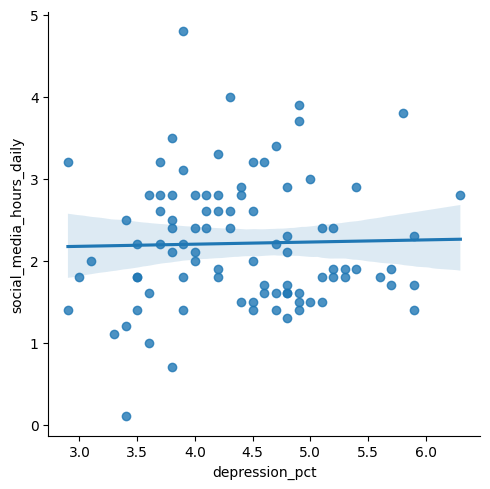

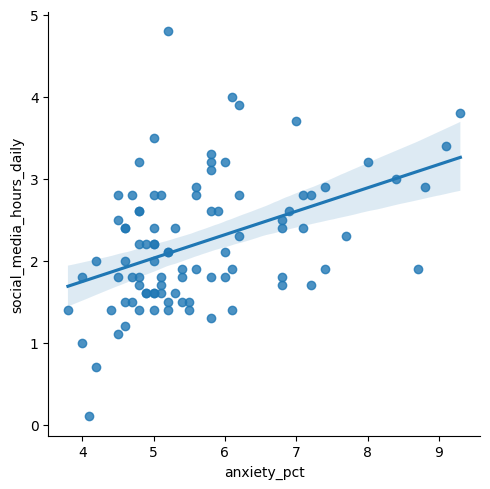

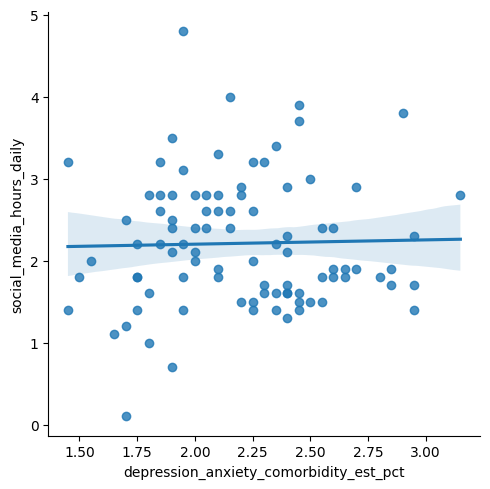

In [56]:


sns.lmplot(data=df,x='depression_pct',y='social_media_hours_daily')
sns.lmplot(data=df,x='anxiety_pct',y='social_media_hours_daily')
sns.lmplot(data=df,x='depression_anxiety_comorbidity_est_pct',y='social_media_hours_daily')

we can see that the strongest correlation is between anxiety and screentime

COVID-19 aftermath — which regions saw the largest pandemic-era mental health surge?

In [58]:
largest_effect = df.sort_values("covid_mh_increase_pct",ascending=False)[:10]
largest_effect['covid_mh_increase_pct']

0     86
1     85
2     82
3     82
4     80
5     80
7     72
9     72
11    72
6     71
Name: covid_mh_increase_pct, dtype: int64

<Axes: xlabel='covid_mh_increase_pct', ylabel='country'>

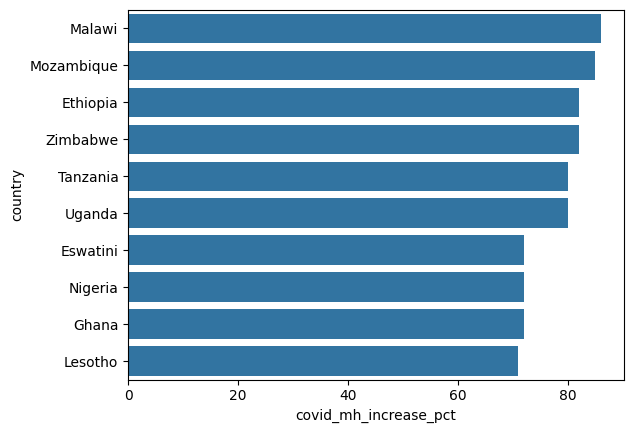

In [60]:
sns.barplot(data=largest_effect,y="country",x='covid_mh_increase_pct')

we can assume that the most affected region is the african region given that the top 10 affected countries all are from africa

Inequality research — compare high-income vs. low-income country disparities in care access

<Axes: xlabel='income_group', ylabel='treatment_gap_pct'>

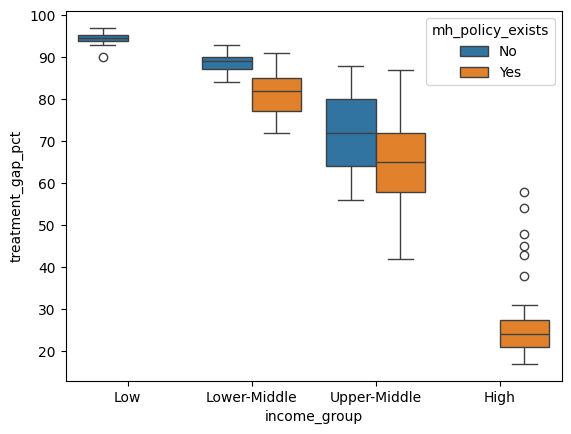

In [71]:
sns.boxplot(data=df,y='treatment_gap_pct',x='income_group',hue="mh_policy_exists")

<Axes: xlabel='income_group', ylabel='treatment_gap_pct'>

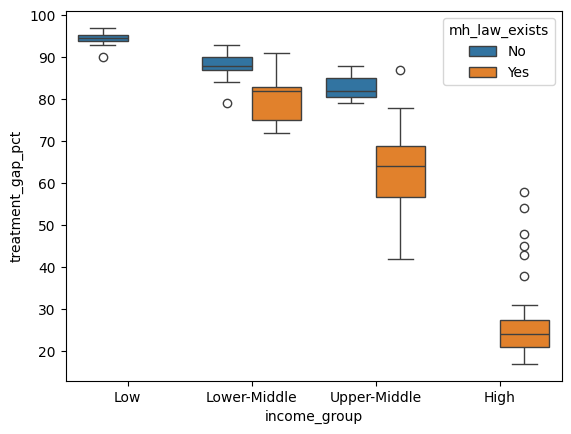

In [70]:
sns.boxplot(data=df,y='treatment_gap_pct',x='income_group',hue="mh_law_exists")

Policy analysis — examine the impact of mental health laws and budgets on treatment gaps

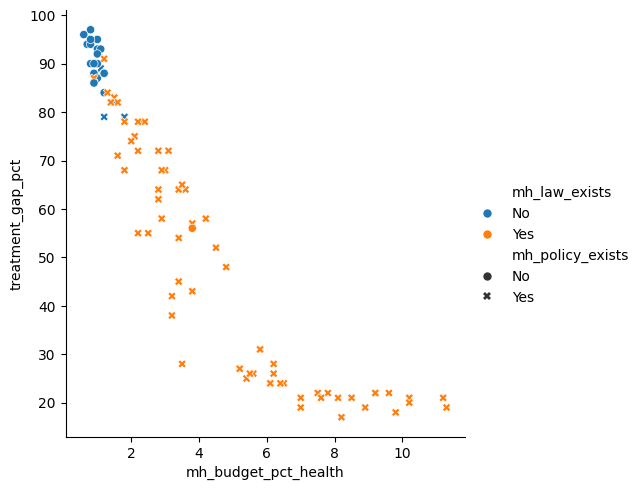

In [72]:
sns.relplot(data=df,x="mh_budget_pct_health",y='treatment_gap_pct',hue="mh_law_exists",style="mh_policy_exists")

Clustering & segmentation — group countries by mental health burden, system strength, or income level

In [ ]:
sns.pairplot(df, vars=, hue="cluster")